<a href="https://colab.research.google.com/github/Ayushwan2004/Ayushwan2004/blob/main/DL_Updated_BostonHousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("HousingData.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (506, 14)

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [4]:
df.fillna(df.median(), inplace=True)
print("\nAfter filling NaNs:")
print(df.isnull().sum())


After filling NaNs:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [5]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]
print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)



Feature shape: (506, 13)
Target shape: (506,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (404, 13)
Test set size: (102, 13)


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  # Output layer (no activation for regression)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 535.3012 - mae: 21.0592 - val_loss: 364.7905 - val_mae: 17.3038
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 239.1923 - mae: 12.9389 - val_loss: 51.2790 - val_mae: 5.2150
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 59.8399 - mae: 5.8687 - val_loss: 29.5173 - val_mae: 3.7948
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 28.9687 - mae: 3.9652 - val_loss: 28.8760 - val_mae: 3.8275
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 22.3127 - mae: 3.4682 - val_loss: 24.0295 - val_mae: 3.3888
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 19.6388 - mae: 3.1975 - val_loss: 23.0609 - val_mae: 3.2589
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.2340 - mae: 3.0047 - val_loss: 21.2891 - val_mae: 3.1765
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.5430 - mae: 2.8131 - val_loss: 21.1869 - val_mae: 3.2647
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━

In [12]:
y_pred = model.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [15]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nMean Squared Error :", round(mse, 4))
print("R2 Score           :", round(r2, 4))


Mean Squared Error : 14.6575
R2 Score           : 0.8001


In [16]:
print("\nActual Price vs Predicted Price\n")
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual:.2f}  |  Predicted: {predicted[0]:.2f}")


Actual Price vs Predicted Price

Actual: 23.60  |  Predicted: 26.97
Actual: 32.40  |  Predicted: 37.74
Actual: 13.60  |  Predicted: 16.85
Actual: 22.80  |  Predicted: 23.65
Actual: 16.10  |  Predicted: 16.53
Actual: 20.00  |  Predicted: 19.43
Actual: 17.80  |  Predicted: 18.87
Actual: 14.00  |  Predicted: 15.08
Actual: 19.60  |  Predicted: 20.73
Actual: 16.80  |  Predicted: 17.62


In [17]:
plt.figure(figsize=(12, 4))


<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

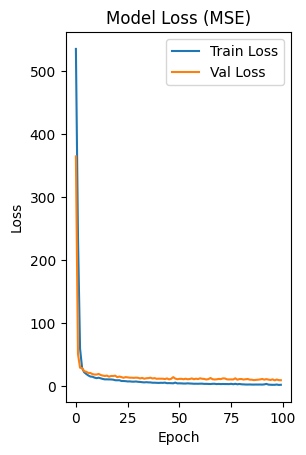

In [18]:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

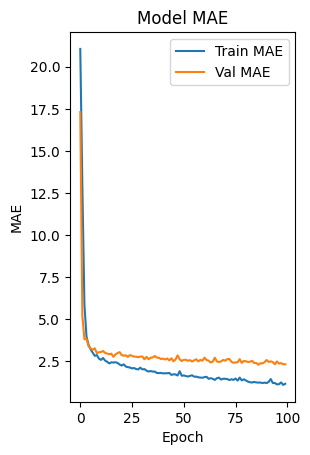

In [19]:
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

In [20]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

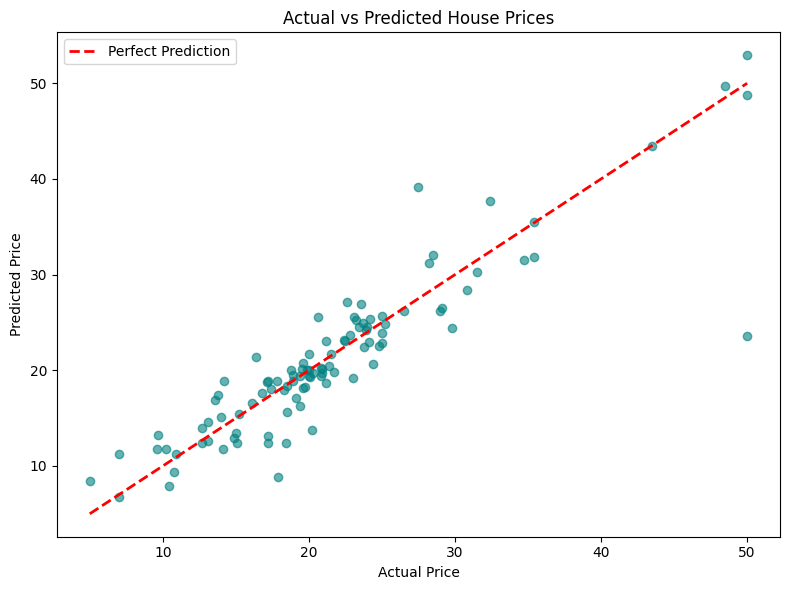

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()